# Task B5:
Transform the original grayscale image and the periodic noisy image from the spatial domain to the frequency domain using the Fourier transform by doing the following steps:
- Compute the 2D Fourier transform of the original grayscale image.
- Shift the zero-frequency component to the center, then display the magnitude spectrum.
- Compare the Fourier spectrum of the original image and the periodic noisy image.

### The original and periodic noisy image

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

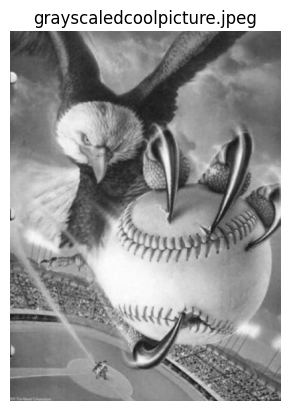

In [ ]:
image = cv2.imread("grayscaledcoolpicture.jpeg", 0)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("grayscaledcoolpicture.jpeg")
plt.show()

In [37]:
noisy_image=image.copy()

def add_periodic_noise(image, amplitude, frequency):
    x = np.arange(image.shape[1])
    periodic = amplitude * np.sin(2 * np.pi * frequency * x)
    periodic = np.tile(periodic, (image.shape[0], 1))
    noisy = image[:,:] + periodic
    image[:,:] = noisy

add_periodic_noise(noisy_image,30,0.1)

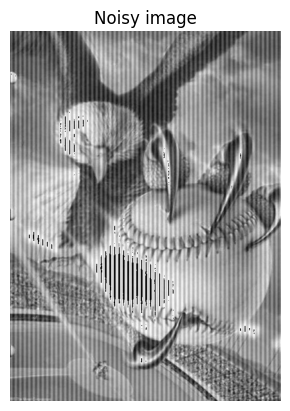

In [38]:
plt.imshow(noisy_image, cmap="gray")
plt.axis("off")
plt.title("Noisy image")
plt.show()

### 2D Fourier transform

In [45]:
# The 2D Fourier transform
dft = cv2.dft(np.float64(image), flags=cv2.DFT_COMPLEX_OUTPUT)

# Shift the zero-frequency component to the center
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

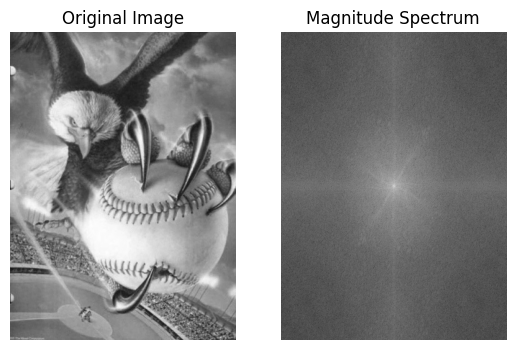

In [46]:
plt.subplot(121)
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(122)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.axis("off")
plt.title("Magnitude Spectrum")

plt.show()

In [47]:
dft_noisy = cv2.dft(np.float64(noisy_image), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift_noisy = np.fft.fftshift(dft_noisy)
magnitude_spectrum_noisy = 20*np.log(cv2.magnitude(dft_shift_noisy[:,:,0],dft_shift_noisy[:,:,1]))

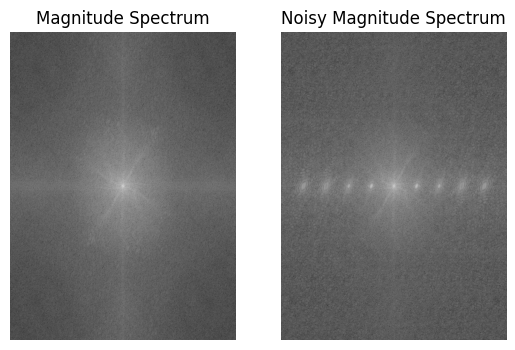

In [48]:
plt.subplot(121)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.axis("off")
plt.title("Magnitude Spectrum")

plt.subplot(122)
plt.imshow(magnitude_spectrum_noisy, cmap="gray")
plt.axis("off")
plt.title("Noisy Magnitude Spectrum")

plt.show()

# Task B6:
Perform noise removal on the periodic noisy image using frequency-domain filtering by doing the following steps:
- Use the Fourier spectrum of the periodic noisy image.
- Choose a frequency-domain filter taught in the lectures to perform filtering. Explain your choice.
- Perform Inverse Fourier Transform to convert the filtered image from frequency domain back to spatial domain.
- Then display:
    - The periodic noisy image;
    - The Fourier spectrum before filtering;
    - The Fourier spectrum after filtering;
    - The restored image after inverse Fourier transform

In [92]:
# We need to use a low-pass filter because it is used for smoothing an image and smoothing is how we remove the noises from an image
# Ideal LPF
rows, cols = image.shape
center_row, center_col = rows//2 , cols//2
mask = np.zeros((rows,cols,2),np.uint8)
mask[center_row-50:center_row+51, center_col-50:center_col+51] = 1

In [91]:
# Applying the mask
f_shift_noisy = dft_shift_noisy*mask
magnitude_spectrum_filtered = 20*np.log(cv2.magnitude(f_shift_noisy[:,:,0],f_shift_noisy[:,:,1]))
# Performing inverse DFT
f_ishift_noisy = np.fft.ifftshift(f_shift_noisy)
image_back = cv2.idft(f_ishift_noisy)
image_back = cv2.magnitude(image_back[:,:,0],image_back[:,:,1])

C:\Users\sprin\AppData\Local\Temp\ipykernel_9248\1296508793.py:3: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum_filtered = 20*np.log(cv2.magnitude(f_shift_noisy[:,:,0],f_shift_noisy[:,:,1]))


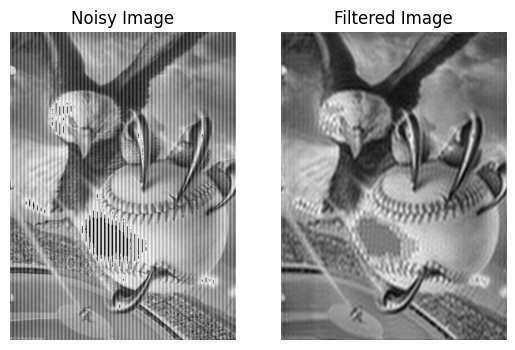

In [93]:
plt.subplot(121)
plt.imshow(noisy_image, cmap="gray")
plt.axis("off")
plt.title("Noisy Image")

plt.subplot(122)
plt.imshow(image_back, cmap="gray")
plt.axis("off")
plt.title("Filtered Image")

plt.show()

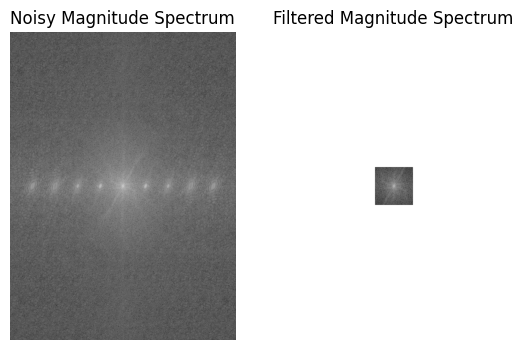

In [94]:
plt.subplot(121)
plt.imshow(magnitude_spectrum_noisy, cmap="gray")
plt.axis("off")
plt.title("Noisy Magnitude Spectrum")

plt.subplot(122)
plt.imshow(magnitude_spectrum_filtered, cmap="gray")
plt.axis("off")
plt.title("Filtered Magnitude Spectrum")

plt.show()